# 第 6 章 · 图谱多跳与路径排序

[章节网页](../ch6.html)

## 运行内容

- 加载三元组图谱
- 运行多跳查询
- 输出路径排序

## 0. 环境与数据

In [1]:
# 准备运行时：若下载单个 ipynb 后本地没有 labs/，会自动拉取所需脚本和数据。
import importlib.util
import subprocess
import sys
from pathlib import Path
from urllib.request import urlretrieve

BASE_URL = "https://raw.githubusercontent.com/zhesun-0209/ai-thinking-labs/main"
RUNTIME_FILES = ['labs/ch06/reasoning.py', 'labs/common/campus_graph.json', 'labs/common/ch6_kg.json', 'labs/common/ch6_rules.json', 'labs/common/codelens.py', 'labs/common/luxun_bpe.json', 'labs/common/mpl_setup.py', 'labs/common/notebook_helpers.py', 'labs/common/viz_anim.py']

ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if not (ROOT / "labs").exists():
    ROOT = Path.cwd() / "_ai_thinking_labs_runtime"
    for rel in RUNTIME_FILES:
        target = ROOT / rel
        if target.exists():
            continue
        target.parent.mkdir(parents=True, exist_ok=True)
        urlretrieve(f"{BASE_URL}/{rel}", target)

missing = []
for module, package in [
    ("numpy", "numpy>=1.24"),
    ("pandas", "pandas>=2.0"),
    ("matplotlib", "matplotlib>=3.7"),
    ("scipy", "scipy>=1.10"),
    ("sklearn", "scikit-learn>=1.3"),
]:
    if importlib.util.find_spec(module) is None:
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch06"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
print("runtime ready:", ROOT)
from reasoning import *

runtime ready: /Users/zhesun/Desktop/Fudan/phd/vibe coding


In [2]:
# 保存本步骤变量，供后续代码单元使用。
kg = load_kg()

In [3]:
# 显示当前实验结果表。
display(kg_query_table())

,项目,内容
0,查询模板,"[鲁迅, 创作, ?X, ?X, 发表于, ?Y]"
1,答案 Y,文学周报社


In [4]:
# 显示当前实验结果表。
display(graph_edges_table())

,头实体,关系,尾实体
0,鲁迅,创作,狂人日记
1,鲁迅,创作,呐喊
2,狂人日记,发表于,文学周报社
3,呐喊,发表于,文学周报社
4,狂人日记,获得,茅盾文学奖
5,莫言,创作,蛙
6,莫言,创作,红高粱
7,蛙,获得,茅盾文学奖
8,红高粱,入选,典藏
9,红高粱,改编,电影


In [5]:
# 保存本步骤变量，供后续代码单元使用。
adj = build_adj(kg)

In [6]:
# 显示当前实验结果表。
display(entity_out_edges('鲁迅'))

,实体,关系,指向
0,鲁迅,创作,狂人日记
1,鲁迅,创作,呐喊


## 1. 多跳查询

In [7]:
# 显示当前实验结果表。
display(graph_multihop_table())

,跳数,输入,关系约束,候选
0,1,鲁迅,创作,狂人日记；呐喊
1,2,狂人日记,发表于,文学周报社
2,2,呐喊,发表于,文学周报社
3,汇总,所有作品,共同 Y,文学周报社 ✓


## 2. 路径排序

In [8]:
# 显示当前实验结果表。
display(path_ranking_table())

,路径,得分
0,蛙→茅盾文学奖,3
2,红高粱→电影→金熊奖,3
1,红高粱→典藏,2


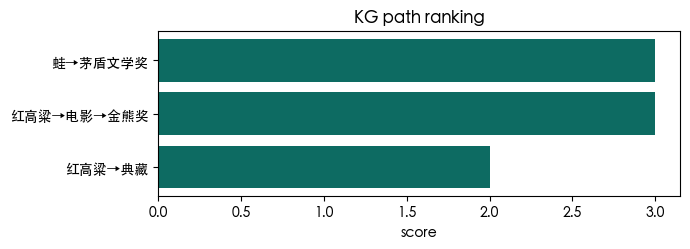

In [9]:
# 绘制当前实验图。
plot_path_ranking()